# Your assignment

## Right now: email me a description of the energy function you want to use. I need to know if you care about height of players, offensive ranking of teams, overall rankings of teams, etc. I need to know that ASAP so that I can make sure to have the data available.

## After Selection Sunday, I will update this, and you can fill out the below. Here's what you'll do:


1. Grab the code. Here's where it lives on github: [https://github.com/mglerner/MarchMadnessMonteCarlo]. You can either grab it via git if you know how, or by clicking on the code button and downloading a zip file.

2. Unzip the code if you downloaded it as zip file.

3. Start up jupyter lab from the directory where the zip file was.

4. Follow the directions below

5. When you're all done, email me a copy of your notebook.

In [1]:
# Import all of the things we need

import seaborn as sns
sns.set_style('darkgrid')
import numpy as np
from matplotlib import pyplot as plt
import imp
from MarchMadnessMonteCarlo import KenPomeroy
imp.reload(KenPomeroy)
import MarchMadnessMonteCarlo as MMMC
imp.reload(MMMC)

/var/folders/4w/ssz2zjl56pxgf3w8b2b78c2c0000gr/T/ipykernel_71924/904730506.py:7: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


<module 'MarchMadnessMonteCarlo' from '/Users/mglerner/coding/MarchMadnessMonteCarlo/MarchMadnessMonteCarlo/__init__.py'>

In [3]:
# Verify that you can print out a bracket
teams = MMMC.Teams['south']
b = MMMC.Bracket(teams=teams,T=0.5)
print (b)

N. Carolina (1)                                              
Texas So. (16)            N.  (1)                            
Arkansas (8)                                                 
Seton Hall (9)            Set (9)  N.  (1)                   
Minnesota (5)                                                
Middle Tenn. (12)         Mid (12)                           
Butler (4)                                                   
Winthrop (13)             Win (13) Win (13) N.  (1)          
Cincinnati (6)            Kan (11) Kan (11) Kan (11) N.  (1) 
Kansas St. (11)                                              
UCLA (3)                  UCL (3)                            
Kent St. (14)                                                
Dayton (7)                Day (7)  Ken (2)                   
Wichita St. (10)                                             
Kentucky (2)              Ken (2)                            
N. Kentucky (15)                                             
Total br

### Now define your energy function

The code below makes one called `defensive_energy_gain`. You want to make your own, and set the MMMC energy function to your function. So, you'll need to define your own function, and then change the last line in the below cell to point to yours instead of `defensive_energy_gain`

In [4]:
def defensive_energy_gain(winner,loser):
    strength = MMMC.RAS.kenpom['AdjD']
    # Lower numbers are better
    A,B = strength[winner], strength[loser]
    result = A/B
    #result = A-B
    return result



MMMC.set_energy_function(defensive_energy_gain)

### What should temperature be?

Now, what should our actual temperature be? Historically, we know that an 8 seed vs. a 9 seed should essentially be a tossup. So, as a proxy here, we could just look at the chance of an 8 seed winning over a range of temperatures, and pick the point where it's pretty close to 0.5.

Here are two functions that help us look at that:

In [6]:
def winpct8(team8,team9,T,numtrials=1000):
    results = [MMMC.playgame(team8,team9,T)[0] == team8 for i in range(numtrials)]
    return np.average(results)
def plotwins(team8,team9,numtrials=1000,tmin=0,tmax=1,numtemps=100):
    Ts = np.linspace(tmin,tmax,numtemps)
    pct = [winpct8(team8,team9,T,numtrials) for T in Ts]
    plt.plot(Ts,pct,label='{t1} vs. {t2}'.format(t1=team8,t2=team9))
    plt.xlabel('T')
    plt.ylabel('winpct')

### How do we actually decide on temperature?

We want to pick a temperature where the results converge to about 50%. That may or may not be possible, so you just do your best.

You want to change some things in your calls to plotwins below as you play around.

* tmin is the lowest temperature you care about. This can probably stay at 0.
* tmax is the biggest you care about. some of our functions wanted that at 1, some wanted it as big as 50. You want it to be big enough to see convergence, but small enough that you can really see the part that closes in on 50%.
* numtrials: start this at 100 or 1000 to make it run quickly. Then, when you think you have a good range, set it to 10000 so the curve is more converged.

/Users/mglerner/coding/MarchMadnessMonteCarlo/MarchMadnessMonteCarlo/Brackets.py:63: RuntimeWarning: divide by zero encountered in double_scalars
  boltzmann_factor = exp(-ediff/T)


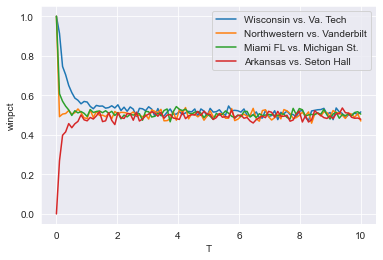

In [7]:
tmin = 0
tmax = 10
numtemps = 100
numtrials = 1000
plt.clf()
plotwins('Wisconsin','Va. Tech',numtrials=numtrials,tmin=tmin,tmax=tmax,numtemps=numtemps)
plotwins('Northwestern','Vanderbilt',numtrials=numtrials,tmin=tmin,tmax=tmax,numtemps=numtemps)
plotwins('Miami FL','Michigan St.',numtrials=numtrials,tmin=tmin,tmax=tmax,numtemps=numtemps)
plotwins('Arkansas',"Seton Hall",numtrials=numtrials,tmin=tmin,tmax=tmax,numtemps=numtemps)
plt.legend()
plt.show()